# 뉴스 감성분석 테스트 (KR-FinBERT)

## 목적
- `snunlp/KR-FinBert-SC` 모델이 한국어 금융 뉴스에서 감성을 올바르게 분류하는지 검증
- 네이버 뉴스 API 연동 확인
- `/company` 엔드포인트에 사용할 `services/sentiment.py` 로직 검증

## 모델 정보
| 항목 | 내용 |
|---|---|
| 모델 | `snunlp/KR-FinBert-SC` |
| 베이스 | KLUE-BERT |
| 학습 데이터 | 한국어 금융 뉴스 (SNU 금융 말뭉치) |
| 출력 | positive / negative / neutral |

> DART 분류기와 달리 **파인튜닝 없이** 사전학습 모델 그대로 사용합니다.

## 1. KR-FinBERT 모델 로드

In [1]:
from transformers import pipeline

MODEL = "snunlp/KR-FinBert-SC"

sentiment_pipe = pipeline(
    "text-classification",
    model=MODEL,
    tokenizer=MODEL,
    device="cpu",
    truncation=True,
    max_length=256,
)

print("모델 로드 완료:", MODEL)

config.json:   0%|          | 0.00/881 [00:00<?, ?B/s]

c:\Users\vacke\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vacke\.cache\huggingface\hub\models--snunlp--KR-FinBert-SC. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/406M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: snunlp/KR-FinBert-SC
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/406M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

모델 로드 완료: snunlp/KR-FinBert-SC


## 2. 샘플 텍스트 기본 검증

긍정/부정/중립 케이스가 각각 제대로 분류되는지 확인합니다.

In [2]:
LABEL_KO = {"positive": "긍정", "negative": "부정", "neutral": "중립"}

samples = [
    # 긍정
    ("긍정", "삼성전자, 3분기 영업이익 10조원 돌파… 반도체 부문 역대 최대 실적"),
    ("긍정", "카카오 주가 52주 신고가 경신, 외국인 순매수 지속"),
    # 부정
    ("부정", "현대차, 대규모 리콜 발표로 주가 급락… 충당금 1조원 예상"),
    ("부정", "셀트리온 임상 3상 실패 공시, 시간외 거래서 15% 하락"),
    # 중립
    ("중립", "삼성전자, 오는 31일 3분기 실적 발표 예정"),
    ("중립", "한국은행, 기준금리 동결 결정… 시장 예상 부합"),
]

print(f"{'예상':^4} {'예측':^4} {'점수':^6}  제목")
print("-" * 70)

correct = 0
for expected, text in samples:
    result = sentiment_pipe(text[:512])[0]
    pred   = LABEL_KO.get(result["label"].lower(), result["label"])
    score  = round(result["score"], 3)
    match  = "✓" if pred == expected else "✗"
    if pred == expected:
        correct += 1
    print(f"{match} {expected:^4} {pred:^4} {score:.3f}  {text[:50]}")

print(f"\n정확도: {correct}/{len(samples)} ({correct/len(samples)*100:.0f}%)")

 예상   예측    점수    제목
----------------------------------------------------------------------
✓  긍정   긍정  1.000  삼성전자, 3분기 영업이익 10조원 돌파… 반도체 부문 역대 최대 실적
✓  긍정   긍정  1.000  카카오 주가 52주 신고가 경신, 외국인 순매수 지속
✓  부정   부정  1.000  현대차, 대규모 리콜 발표로 주가 급락… 충당금 1조원 예상
✓  부정   부정  0.999  셀트리온 임상 3상 실패 공시, 시간외 거래서 15% 하락
✓  중립   중립  0.591  삼성전자, 오는 31일 3분기 실적 발표 예정
✓  중립   중립  1.000  한국은행, 기준금리 동결 결정… 시장 예상 부합

정확도: 6/6 (100%)


## 3. 네이버 뉴스 API 연동

In [8]:
import os
import re
import requests
from dotenv import load_dotenv

load_dotenv()

NAVER_CLIENT_ID     = os.environ.get("NAVER_CLIENT_ID", "")
NAVER_CLIENT_SECRET = os.environ.get("NAVER_CLIENT_SECRET", "")

# 키가 없으면 직접 입력
if not NAVER_CLIENT_ID:
    NAVER_CLIENT_ID     = input("NAVER_CLIENT_ID: ").strip()
    NAVER_CLIENT_SECRET = input("NAVER_CLIENT_SECRET: ").strip()

NEWS_URL = "https://openapi.naver.com/v1/search/news.json"

def strip_html(text: str) -> str:
    text = re.sub(r"<[^>]+>", "", text)
    return text.replace("&quot;", '"').replace("&amp;", "&").strip()

def fetch_news(corp_name: str, display: int = 10) -> list[dict]:
    res = requests.get(
        NEWS_URL,
        headers={
            "X-Naver-Client-Id":     NAVER_CLIENT_ID,
            "X-Naver-Client-Secret": NAVER_CLIENT_SECRET,
        },
        params={"query": corp_name, "display": display, "sort": "date"},
        timeout=10,
    )
    res.raise_for_status()
    return [
        {
            "title":       strip_html(item.get("title", "")),
            "link":        item.get("link", ""),
            "pub_date":    item.get("pubDate", ""),
            "description": strip_html(item.get("description", "")),
        }
        for item in res.json().get("items", [])
    ]

# 연결 테스트
test_articles = fetch_news("삼성전자", display=3)
print(f"뉴스 조회 성공: {len(test_articles)}건")
for a in test_articles:
    print(f"  [{a['pub_date'][:16]}] {a['title']}")

뉴스 조회 성공: 3건
  [Sun, 26 Apr 2026] 6500 돌파에도 개미는 15조 던졌다…역대급 엇갈린 베팅, 이유는
  [Sun, 26 Apr 2026] 중동 긴장 속 코스피, 6,500선 돌파하며 강세 지속
  [Sun, 26 Apr 2026] 조선·2차전지 ETF 강세…주간 수익률 상위권 포진[펀드와치]


## 4. 기업별 뉴스 감성분석 파이프라인

In [9]:
import pandas as pd

def analyze(corp_name: str, display: int = 10) -> pd.DataFrame:
    articles = fetch_news(corp_name, display)
    if not articles:
        print("뉴스 없음")
        return pd.DataFrame()

    texts   = [f"{a['title']} {a['description']}"[:512] for a in articles]
    results = sentiment_pipe(texts)

    rows = []
    for article, result in zip(articles, results):
        rows.append({
            "제목":     article["title"],
            "발행일":   article["pub_date"][:16],
            "감성":     LABEL_KO.get(result["label"].lower(), result["label"]),
            "신뢰도":   round(result["score"], 3),
        })

    return pd.DataFrame(rows)


CORP = "삼성전자"   # ← 바꿔서 테스트
df = analyze(CORP, display=10)

print(f"\n[{CORP}] 뉴스 감성분석 결과 ({len(df)}건)")
print(df.to_string(index=False))


[삼성전자] 뉴스 감성분석 결과 (10건)
                                        제목              발행일 감성   신뢰도
     6500 돌파에도 개미는 15조 던졌다…역대급 엇갈린 베팅, 이유는 Sun, 26 Apr 2026 부정 0.353
            중동 긴장 속 코스피, 6,500선 돌파하며 강세 지속 Sun, 26 Apr 2026 긍정 1.000
        조선·2차전지 ETF 강세…주간 수익률 상위권 포진[펀드와치] Sun, 26 Apr 2026 긍정 0.999
             반등장서 개미 14조 던졌다…사상 최대 ‘팔자’ 눈앞 Sun, 26 Apr 2026 긍정 0.949
             장난감 대신 삼전닉스 긁었다[사(Buy)는 게 뭔지] Sun, 26 Apr 2026 중립 1.000
SK하이닉스, HBM 혁신 성과 인정 받았다…美 IEEE 기업혁신상 첫 수상 Sun, 26 Apr 2026 긍정 1.000
       "우주냐, 반도체냐" ETF로 몰리는 뭉칫돈...유사상품 쏟아져 Sun, 26 Apr 2026 중립 1.000
[김수현의 상한가] 미-이란 전쟁 보다 실적이 우선…코스피 최고가 또 ... Sun, 26 Apr 2026 긍정 0.899
      SK하닉, 최고 권위 IEEE 기업혁신상 첫 수상…"HBM 혁신" Sun, 26 Apr 2026 긍정 1.000
          역대급 국장 랠리에…미성년 투자자 주식 가치 3조원에 육박 Sun, 26 Apr 2026 중립 1.000


## 5. 감성 비율 요약 + 시각화


[삼성전자] 감성 비율
  긍정: ██████ 6건 (60%)
  중립: ███ 3건 (30%)
  부정: █ 1건 (10%)

  → 전체 감성: [긍정]


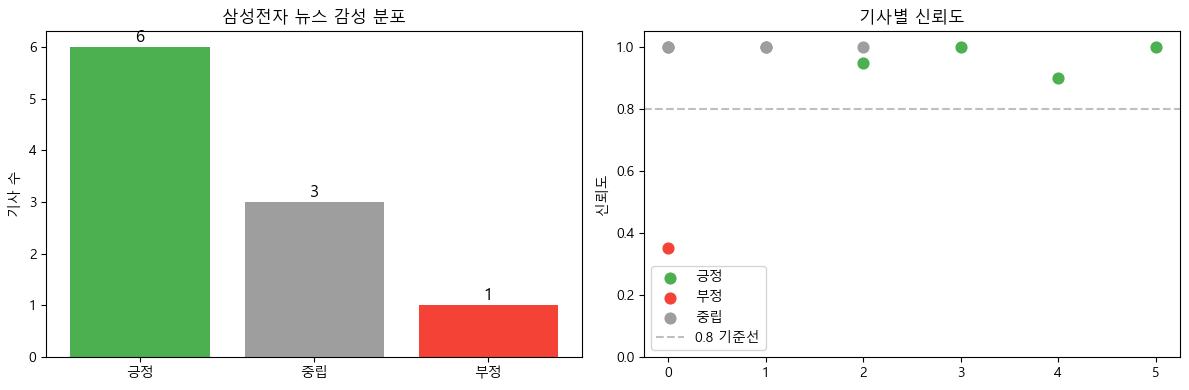

차트 저장: sentiment_삼성전자.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 (환경별 대응)
try:
    plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
except:
    plt.rcParams["font.family"] = "AppleGothic"     # macOS
plt.rcParams["axes.unicode_minus"] = False

counts = df["감성"].value_counts().reindex(["긍정", "중립", "부정"], fill_value=0)
total  = len(df)

print(f"\n[{CORP}] 감성 비율")
for label, cnt in counts.items():
    bar = "█" * cnt
    print(f"  {label}: {bar} {cnt}건 ({cnt/total*100:.0f}%)")

dominant = counts.idxmax()
print(f"\n  → 전체 감성: [{dominant}]")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 막대 그래프
colors = ["#4CAF50", "#9E9E9E", "#F44336"]
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title(f"{CORP} 뉴스 감성 분포")
axes[0].set_ylabel("기사 수")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.1, str(v), ha="center", fontsize=12)

# 신뢰도 분포 (산점도)
palette = {"긍정": "#4CAF50", "중립": "#9E9E9E", "부정": "#F44336"}
for sentiment, group in df.groupby("감성"):
    axes[1].scatter(
        range(len(group)), group["신뢰도"],
        label=sentiment, color=palette.get(sentiment, "gray"), s=60,
    )
axes[1].set_title("기사별 신뢰도")
axes[1].set_ylabel("신뢰도")
axes[1].set_ylim(0, 1.05)
axes[1].axhline(0.8, color="gray", linestyle="--", alpha=0.5, label="0.8 기준선")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"sentiment_{CORP}.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"차트 저장: sentiment_{CORP}.png")

## 6. 복수 기업 비교

  기업  긍정(%)  중립(%)  부정(%) 전체감성  평균신뢰도
삼성전자   60.0   30.0   10.0   긍정  0.920
 카카오   10.0   80.0   10.0   중립  0.927
 현대차   60.0   40.0    0.0   긍정  0.994


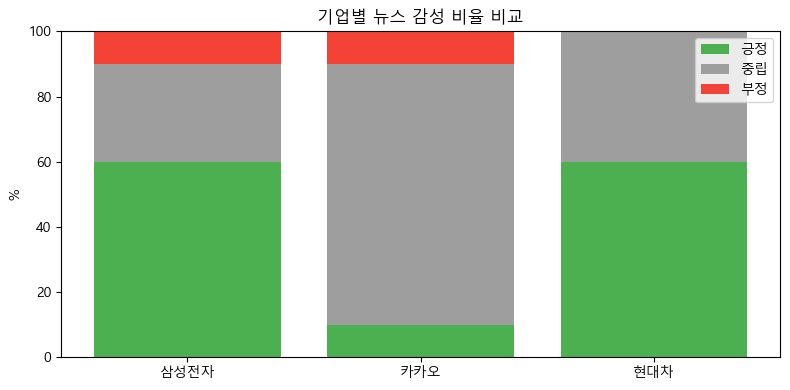

In [11]:
CORPS = ["삼성전자", "카카오", "현대차"]   # ← 비교할 기업 목록

summary_rows = []
for corp in CORPS:
    df_corp = analyze(corp, display=10)
    if df_corp.empty:
        continue
    counts = df_corp["감성"].value_counts().reindex(["긍정", "중립", "부정"], fill_value=0)
    total  = len(df_corp)
    summary_rows.append({
        "기업":     corp,
        "긍정(%)":  round(counts["긍정"] / total * 100, 1),
        "중립(%)":  round(counts["중립"] / total * 100, 1),
        "부정(%)":  round(counts["부정"] / total * 100, 1),
        "전체감성": counts.idxmax(),
        "평균신뢰도": round(df_corp["신뢰도"].mean(), 3),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# 긍정 비율 비교 차트
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(summary_df))
ax.bar(x, summary_df["긍정(%)"], label="긍정", color="#4CAF50")
ax.bar(x, summary_df["중립(%)"], bottom=summary_df["긍정(%)"], label="중립", color="#9E9E9E")
ax.bar(x, summary_df["부정(%)"],
       bottom=summary_df["긍정(%)"] + summary_df["중립(%)"],
       label="부정", color="#F44336")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["기업"])
ax.set_ylabel("%")
ax.set_title("기업별 뉴스 감성 비율 비교")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("sentiment_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. 엣지 케이스 확인

실제 서비스에서 문제가 될 수 있는 케이스를 테스트합니다.

In [12]:
edge_cases = [
    ("빈 텍스트",          ""),
    ("숫자만",             "10,000 500 3.5%"),
    ("512자 초과",         "삼성전자 " * 150),
    ("영어 혼용",          "Samsung Electronics Q3 영업이익 서프라이즈, 시장 예상치 상회"),
    ("HTML 잔여 태그",     "<b>카카오</b> 주가 &amp; 실적 동반 하락"),
]

print(f"{'케이스':<12} {'감성':^4} {'신뢰도':^6}")
print("-" * 40)
for name, text in edge_cases:
    if not text.strip():
        print(f"{name:<12} {'(스킵)':^4}")
        continue
    result = sentiment_pipe(text[:512])[0]
    label  = LABEL_KO.get(result["label"].lower(), result["label"])
    print(f"{name:<12} {label:^4} {result['score']:.3f}")

케이스           감성   신뢰도  
----------------------------------------
빈 텍스트        (스킵)
숫자만           중립  0.916
512자 초과       긍정  0.857
영어 혼용         긍정  1.000
HTML 잔여 태그    부정  0.999
